In [1]:
import importlib
import sys
import pickle
import numpy as np

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../..')
sys.path.insert(0, '../../../../..')
sys.path.insert(0, '../../../../../..')

In [2]:
import src.evaluation_metrics.conduct_evaluation
importlib.reload(src.evaluation_metrics.conduct_evaluation)

import src.evaluation_metrics.metrics
importlib.reload(src.evaluation_metrics.metrics)

<module 'src.evaluation_metrics.metrics' from '/Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/src/notebooks/evaluation_metric_notebooks/improved/Helpdesk/../../../../../src/evaluation_metrics/metrics.py'>

In [3]:
import src.evaluation_metrics.plots
importlib.reload(src.evaluation_metrics.plots)

output_dirs = ['../../../../../evaluation_results/Helpdesk/improved/']

all_results = dict()

event_label_list = ['Assign seriousness', 'Take in charge ticket', 'Resolve ticket', 'Closed', 'Insert ticket', 'Wait', 'Create SW anomaly', 'Require upgrade', 'VERIFIED', 'DUPLICATE', 'Resolve SW anomaly', 'Schedule intervention', 'RESOLVED', 'INVALID']

for output_dir in output_dirs:
    evaluation_metrics = {
        'NormalizedDamerauLevenshteinMeanVar_activity' : src.evaluation_metrics.metrics.NormalizedDamerauLevenshteinDistanceMeanVar('Activity', percentile=0.25),
        'RemainingTime_SUM_Mean_MAE_outliers' : src.evaluation_metrics.metrics.SumValueMeanMAE('event_elapsed_time', percentile=0.25, value_factor = 3600*24),
        'RemainingTime_SUM_Abs_Mean_MAE_outliers' : src.evaluation_metrics.metrics.SumAbsValueMeanMAE('event_elapsed_time', percentile=0.25, value_factor = 3600*24),
        'RemainingTime_LastEvent_Mean2_Var_seconds_outliers' : src.evaluation_metrics.metrics.LastValueMean2VarMAE('case_elapsed_time', percentile=0.25, value_factor= 3600*24),
        'RemainingTime_PIT' : src.evaluation_metrics.metrics.LastValuePIT('case_elapsed_time'),
        'EventElapsed_PIT' : src.evaluation_metrics.metrics.SumValuesPIT('event_elapsed_time'),
        'SuffixCountMAE' : src.evaluation_metrics.metrics.SuffixCountMAE(percentile=0.25),
        
        'SumValuesInterval_50' : src.evaluation_metrics.metrics.SumValuesInterval('event_elapsed_time', percentile=0.5),
        'SumValuesInterval_75' : src.evaluation_metrics.metrics.SumValuesInterval('event_elapsed_time', percentile=0.75),
        'SumValuesInterval_90' : src.evaluation_metrics.metrics.SumValuesInterval('event_elapsed_time', percentile=0.90),
        'SumValuesInterval_95' : src.evaluation_metrics.metrics.SumValuesInterval('event_elapsed_time', percentile=0.95),
        'SumValuesInterval_99' : src.evaluation_metrics.metrics.SumValuesInterval('event_elapsed_time', percentile=0.99),

        'LastValueInterval_50' : src.evaluation_metrics.metrics.LastValueInterval('case_elapsed_time', percentile=0.50),
        'LastValueInterval_75' : src.evaluation_metrics.metrics.LastValueInterval('case_elapsed_time', percentile=0.75),
        'LastValueInterval_90' : src.evaluation_metrics.metrics.LastValueInterval('case_elapsed_time', percentile=0.90),
        'LastValueInterval_95' : src.evaluation_metrics.metrics.LastValueInterval('case_elapsed_time', percentile=0.95),
        'LastValueInterval_99' : src.evaluation_metrics.metrics.LastValueInterval('case_elapsed_time', percentile=0.99),

        'SuffixCountInterval_50' : src.evaluation_metrics.metrics.SuffixCountInterval(percentile=0.50),
        'SuffixCountInterval_75' : src.evaluation_metrics.metrics.SuffixCountInterval(percentile=0.75),
        'SuffixCountInterval_90' : src.evaluation_metrics.metrics.SuffixCountInterval(percentile=0.90),
        'SuffixCountInterval_95' : src.evaluation_metrics.metrics.SuffixCountInterval(percentile=0.95),
        'SuffixCountInterval_99' : src.evaluation_metrics.metrics.SuffixCountInterval(percentile=0.99),

        'EventLabelCountInterval_50' : src.evaluation_metrics.metrics.EventLabelCountInterval('Activity', event_label_list, percentile=0.50),
        'EventLabelCountInterval_75' : src.evaluation_metrics.metrics.EventLabelCountInterval('Activity', event_label_list, percentile=0.75),
        'EventLabelCountInterval_90' : src.evaluation_metrics.metrics.EventLabelCountInterval('Activity', event_label_list, percentile=0.90),
        'EventLabelCountInterval_95' : src.evaluation_metrics.metrics.EventLabelCountInterval('Activity', event_label_list, percentile=0.95),
        'EventLabelCountInterval_99' : src.evaluation_metrics.metrics.EventLabelCountInterval('Activity', event_label_list, percentile=0.99),


    }

    res_raw, c = src.evaluation_metrics.conduct_evaluation.batch_evaluate(output_dir, evaluation_metrics)
    #res_raw, c = src.evaluation_metrics.conduct_evaluation.evaluate_sequentially(output_dir, evaluation_metrics)
    all_results[output_dir] = (res_raw, c)

with open("Helpdesk_eval.pkl", "wb") as file:
    pickle.dump(all_results, file)

Error: results_part_3356.pkl: division by zero


dict_keys(['NormalizedDamerauLevenshteinMeanVar_activity', 'RemainingTime_SUM_Mean_MAE_outliers', 'RemainingTime_SUM_Abs_Mean_MAE_outliers', 'RemainingTime_LastEvent_Mean2_Var_seconds_outliers', 'RemainingTime_PIT', 'EventElapsed_PIT', 'SuffixCountMAE', 'SumValuesInterval_50', 'SumValuesInterval_75', 'SumValuesInterval_90', 'SumValuesInterval_95', 'SumValuesInterval_99', 'LastValueInterval_50', 'LastValueInterval_75', 'LastValueInterval_90', 'LastValueInterval_95', 'LastValueInterval_99', 'SuffixCountInterval_50', 'SuffixCountInterval_75', 'SuffixCountInterval_90', 'SuffixCountInterval_95', 'SuffixCountInterval_99', 'EventLabelCountInterval_50', 'EventLabelCountInterval_75', 'EventLabelCountInterval_90', 'EventLabelCountInterval_95', 'EventLabelCountInterval_99'])
27
18
18
dict_keys([('SuffixCountMAE', 'Suffix length MAE'), ('NormalizedDamerauLevenshteinMeanVar_activity', 'DLS'), ('RemainingTime_SUM_Mean_MAE_outliers', 'Rem. time (event sum) MAE (days) '), ('SuffixCountInterval_50', 'S

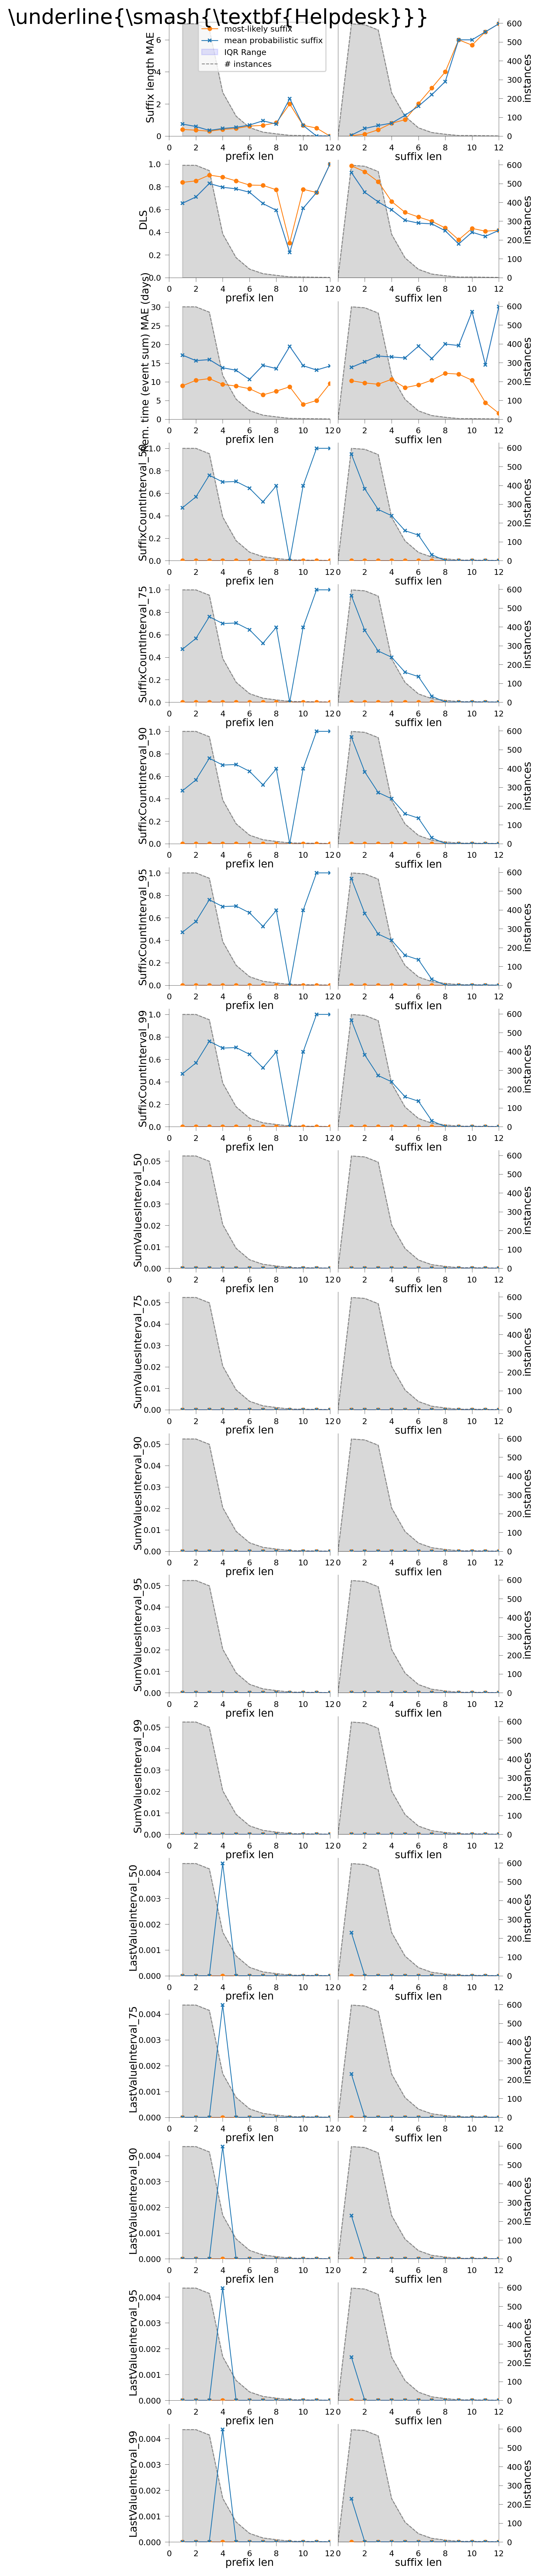

In [4]:
with open("Helpdesk_eval.pkl", "rb") as file:
    all_results = pickle.load(file)

import src.evaluation_metrics.plots
importlib.reload(src.evaluation_metrics.plots)

res_raw, c = all_results['../../../../../evaluation_results/Helpdesk/improved/']

keys_to_keep = [
                ('SuffixCountMAE', 'Suffix length MAE'),
                ('NormalizedDamerauLevenshteinMeanVar_activity', 'DLS'),
                ('RemainingTime_SUM_Mean_MAE_outliers', 'Rem. time (event sum) MAE (days) '),
                ('SuffixCountInterval_50', 'SuffixCountInterval_50'),
                ('SuffixCountInterval_75', 'SuffixCountInterval_75'),
                ('SuffixCountInterval_90', 'SuffixCountInterval_90'),
                ('SuffixCountInterval_95', 'SuffixCountInterval_95'),
                ('SuffixCountInterval_99', 'SuffixCountInterval_99'),


                ('SumValuesInterval_50', 'SumValuesInterval_50'),
                ('SumValuesInterval_75', 'SumValuesInterval_75'),
                ('SumValuesInterval_90', 'SumValuesInterval_90'),
                ('SumValuesInterval_95', 'SumValuesInterval_95'),
                ('SumValuesInterval_99', 'SumValuesInterval_99'),

                ('LastValueInterval_50', 'LastValueInterval_50'),
                ('LastValueInterval_75', 'LastValueInterval_75'),
                ('LastValueInterval_90', 'LastValueInterval_90'),
                ('LastValueInterval_95', 'LastValueInterval_95'),
                ('LastValueInterval_99', 'LastValueInterval_99'),
]

res = {(k, label) : res_raw[k] for k, label in keys_to_keep}
print(res_raw.keys())
print(len(res_raw.keys()))
print(len(res.keys()))
print(len(keys_to_keep))
print(res.keys())
p = src.evaluation_metrics.plots.plot_res(res, c, columns=2, caption='Helpdesk', pgf=False)#int(len(keys_to_keep)))
if p is not None:
    if p is not None:
        with open('Helpdesk.pgf', 'wb') as f:
            f.write(p)

In [5]:
print('Suffix length MAE')
print(np.mean([i['mean'] for i in res_raw['SuffixCountMAE'].values()]))
print('Probabilistic suffix length MAE')
print(np.mean([i['prob'][0] for i in res_raw['SuffixCountMAE'].values()]))

print('DLS')
print(np.mean([i['mean'] for i in res_raw['NormalizedDamerauLevenshteinMeanVar_activity'].values()]))
print('Probabilistic DLS')
print(np.mean([i['prob'][0] for i in res_raw['NormalizedDamerauLevenshteinMeanVar_activity'].values()]))

print('Mean MAE sum remaining time:')
print(np.mean([i['mean'] for i in res_raw['RemainingTime_SUM_Mean_MAE_outliers'].values()]))
print('Probabilistic MAE sum remaining time:')
print(np.mean([i['prob'][0] for i in res_raw['RemainingTime_SUM_Mean_MAE_outliers'].values()]))

print('Mean MAE last event:')
print(np.mean([i['mean'] for i in res_raw['RemainingTime_LastEvent_Mean2_Var_seconds_outliers'].values()]))
print('Probabilistic MAE last event:')
print(np.mean([i['prob'][0] for i in res_raw['RemainingTime_LastEvent_Mean2_Var_seconds_outliers'].values()]))


Suffix length MAE
0.3866359447004608
Probabilistic suffix length MAE
0.567741935483871
DLS
0.8627750014961997
Probabilistic DLS
0.7378556300330494
Mean MAE sum remaining time:
9.791971283200203
Probabilistic MAE sum remaining time:
15.667109610538741
Mean MAE last event:
7.863974196305674
Probabilistic MAE last event:
11.068386290016152


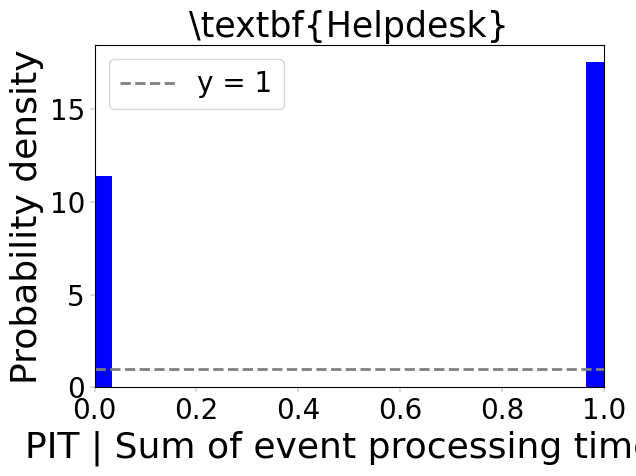

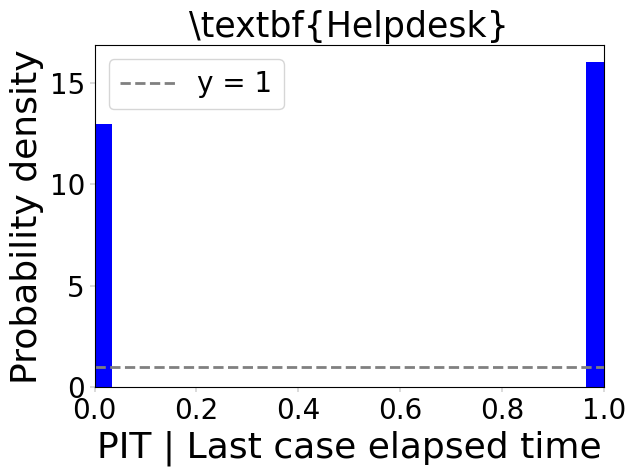

In [6]:
import src.evaluation_metrics.plots
importlib.reload(src.evaluation_metrics.plots)

# pgf=False -> plot_pits returns None; only persist the .pgf bytes when LaTeX is enabled.
r = src.evaluation_metrics.plots.plot_pits(res_raw['EventElapsed_PIT'], caption='Helpdesk', x_label='Sum of event processing times', pgf=False)
if r is not None:
    with open('Helpdesk_PIT_event_elapsed.pgf', 'wb') as f:
        f.write(r)

r = src.evaluation_metrics.plots.plot_pits(res_raw['RemainingTime_PIT'], caption='Helpdesk', x_label='Last case elapsed time', pgf=False)
if r is not None:
    with open('Helpdesk_PIT_remaining_time.pgf', 'wb') as f:
        f.write(r)

In [7]:
res_raw['SuffixCountInterval_50']

{('Case 1132', 1, 3): {'mean': 0, 'prob': (np.True_, (0, 0))},
 ('Case 1132', 2, 2): {'mean': 0, 'prob': (np.False_, (0, 0))},
 ('Case 1132', 3, 1): {'mean': 0, 'prob': (np.True_, (0, 0))},
 ('Case 4475', 1, 3): {'mean': 0, 'prob': (np.False_, (0, 0))},
 ('Case 4475', 2, 2): {'mean': 0, 'prob': (np.True_, (0, 0))},
 ('Case 4475', 3, 1): {'mean': 0, 'prob': (np.True_, (0, 0))},
 ('Case 3148', 1, 3): {'mean': 0, 'prob': (np.True_, (0, 0))},
 ('Case 3148', 2, 2): {'mean': 0, 'prob': (np.False_, (0, 0))},
 ('Case 3148', 3, 1): {'mean': 0, 'prob': (np.True_, (0, 0))},
 ('Case 4169', 1, 3): {'mean': 0, 'prob': (np.True_, (0, 0))},
 ('Case 4169', 2, 2): {'mean': 0, 'prob': (np.True_, (0, 0))},
 ('Case 4169', 3, 1): {'mean': 0, 'prob': (np.True_, (0, 0))},
 ('Case 1273', 1, 3): {'mean': 0, 'prob': (np.True_, (0, 0))},
 ('Case 1273', 2, 2): {'mean': 0, 'prob': (np.False_, (0, 0))},
 ('Case 1273', 3, 1): {'mean': 0, 'prob': (np.True_, (0, 0))},
 ('Case 827', 1, 4): {'mean': 0, 'prob': (np.True_,